# **Protein Embeddings with ESM-2**

Welcome to the Neural Network practice Day 6!

In this session, we will explore **Evolutionary Scale Modeling (ESM)** embeddings. These are powerful representations of protein sequences learned by transformer models trained on billions of protein sequences. We will use Hugging Face `transformers` to load ESM models and analyze protein similarities using embedding distances.

## **Module Imports**

To work with protein embeddings, we need:
- `torch`: The core PyTorch library
- `transformers`: Hugging Face library to load ESM models
- `scikit-learn`: For dimensionality reduction (PCA)
- `matplotlib` & `seaborn`: For static and 2D/3D plotting
- `ipywidgets` & `IPython.display`: For interactive widgets
- `plotly`: For interactive figures

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
from transformers import AutoTokenizer, EsmModel
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import umap
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

ModuleNotFoundError: No module named 'seaborn'

---

## **Understanding ESM Embeddings**

ESM (Evolutionary Scale Modeling) models are "Protein Language Models". Just as BERT or GPT understand human language, ESM understands the "language of life"—amino acid sequences.

### **How it works:**
1. **Tokenization**: A protein sequence (e.g., `MKV...`) is broken into individual amino acids (tokens).
2. **Transformer Layers**: The model processes these tokens, capturing dependencies between amino acids.
3. **Embedding Extraction**: We take the internal mathematical representation (a high-dimensional vector aka tensor) from the model's layers. This vector represents the "meaning" of the protein in a biological/functional space based on what the model learned (it is not always true and can make mistakes as chatGPT can make).

### **The Embedding Vector:**
- A single protein is compressed into a vector of fixed size (e.g., 320, 480, or 1280 dimensions depending on the model size).

---

## **Loading ESM-2 from Hugging Face**

We will use the `esm2_t6_8M_UR50D` model. It is a lightweight version (8 million parameters) that runs quickly even on a CPU.

In [40]:
# Load the tokenizer and model
model_name = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = EsmModel.from_pretrained(model_name).to(device)

def get_protein_embedding(sequence):
    """
    Converts a protein sequence into a single 320-dimensional embedding vector.
    We use 'Mean Pooling' (averaging all amino acid vectors).
    """
    # 1. Tokenize and move to device
    inputs = tokenizer(sequence, return_tensors="pt").to(device)
    
    # 2. Forward pass through the model
    with torch.no_grad():
        outputs = model(**inputs)
    
    # 3. Extract the last hidden state (shape: [batch, sequence_length, embedding_dim])
    last_hidden_state = outputs.last_hidden_state
    
    # 4. Mean pooling (average across the sequence length dimension)
    embedding = last_hidden_state.mean(dim=1).cpu().numpy()
    
    return embedding.flatten()

# Test it
test_seq = "MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQPRW"
emb = get_protein_embedding(test_seq)
print(f"Sequence length: {len(test_seq)}")
print(f"Embedding shape: {emb.shape}")

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Sequence length: 38
Embedding shape: (320,)


---

## **Cosine Similarity vs. Euclidean Distance**

When comparing protein embeddings, we usually choose between two metrics. Understanding their difference is crucial for biological interpretation.

### **1. Cosine Similarity**
Measures the **angle** between two vectors. It asks: *"Do these vectors point in the same direction?"*
- **Range**: -1 to 1 (usually 0 to 1 for embeddings).
- **Property**: It is **magnitude-invariant**. If you double the length of a vector but keep its direction, the cosine similarity remains exactly the same.
- **Biological Intuition**: Focuses on the *functional pattern* or *signature* of the protein, regardless of how "strong" or "long" the embedding is.

### **2. Euclidean Distance**
Measures the **straight-line distance** between two points. It asks: *"How far apart are these points in space?"*
- **Range**: 0 to $\infty$.
- **Property**: Sensitive to both **direction and magnitude**.
- **Biological Intuition**: Useful if the model uses vector length to encode information (like structural stability or confidence).

### **Why choose Cosine Similarity for Proteins?**
1. **Curse of Dimensionality**: In high-dimensional spaces (like ESM's 320D), Euclidean distance can become less meaningful as almost all points become "far apart".
2. **Pooling Artifacts**: Since we often average amino acid vectors, a longer protein might naturally have a slightly different magnitude than a shorter one. Cosine similarity ignores these "length" effects and focuses on the sequence signature.
3. **Standard Practice**: Most protein search tools (like FoldSeek or ESM-based searches) use Cosine Similarity because it better captures functional relationships.

---

## **Interactive Comparison: Angle vs. Magnitude**

Use the sliders below to see how changing a vector's **angle** and **magnitude** affects the two metrics differently.

In [ ]:
def vec_from_angles(az_deg, el_deg, mag):
    az = np.radians(az_deg)
    el = np.radians(el_deg)
    return mag * np.array([np.cos(el) * np.cos(az), np.cos(el) * np.sin(az), np.sin(el)])

def update_plot(az_A, el_A, mag_A, az_B, el_B, mag_B):
    plt.close('all')
    v_a_3d = vec_from_angles(az_A, el_A, mag_A)
    v_b_3d = vec_from_angles(az_B, el_B, mag_B)
    v_a_2d = np.array([v_a_3d[0], v_a_3d[1]])
    v_b_2d = np.array([v_b_3d[0], v_b_3d[1]])
    n_a = np.linalg.norm(v_a_3d)
    n_b = np.linalg.norm(v_b_3d)
    cos_sim = np.dot(v_a_3d, v_b_3d) / (n_a * n_b) if (n_a > 1e-10 and n_b > 1e-10) else 0.0
    euc_dist = np.linalg.norm(v_a_3d - v_b_3d)
    
    fig = plt.figure(figsize=(14, 6))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122, projection='3d')
    
    # --- 2D (xy projection) ---
    ax1.plot([0, v_a_2d[0]], [0, v_a_2d[1]], 'b-', lw=3, label='A')
    ax1.plot([0, v_b_2d[0]], [0, v_b_2d[1]], 'r-', lw=3, label='B')
    ax1.plot([v_a_2d[0], v_b_2d[0]], [v_a_2d[1], v_b_2d[1]], 'g--', lw=2, label='Euc dist')
    n_a_2d = np.linalg.norm(v_a_2d)
    n_b_2d = np.linalg.norm(v_b_2d)
    if n_a_2d > 1e-10 and n_b_2d > 1e-10:
        angle_a = np.arctan2(v_a_2d[1], v_a_2d[0])
        angle_between = np.arccos(np.clip(np.dot(v_a_2d, v_b_2d) / (n_a_2d * n_b_2d), -1.0, 1.0))
        arc_r = 0.35
        t = np.linspace(0, 1, 40)
        arc_angles = angle_a + t * angle_between
        ax1.plot(arc_r * np.cos(arc_angles), arc_r * np.sin(arc_angles), 'm-', lw=2.5, label='angle θ')
        mid = angle_a + angle_between / 2
        label_r = arc_r + 0.15
        ax1.text(label_r * np.cos(mid), label_r * np.sin(mid), f"θ = {np.degrees(angle_between):.0f}°", fontsize=12, color='purple', fontweight='bold')
        ax1.text(0.02, 0.98, f"cos θ = {cos_sim:.3f}", transform=ax1.transAxes, fontsize=13, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax1.scatter(0, 0, c='k', s=20)
    limit_2d = max(1.5, mag_A + 0.5, mag_B + 0.5)
    ax1.set_xlim(-limit_2d, limit_2d)
    ax1.set_ylim(-limit_2d, limit_2d)
    ax1.set_aspect('equal')
    ax1.axhline(0, color='gray', lw=0.5)
    ax1.axvline(0, color='gray', lw=0.5)
    ax1.set_title('2D view (xy projection)')
    ax1.legend(loc='upper right')
    
    # --- 3D ---
    ax2.plot([0, v_a_3d[0]], [0, v_a_3d[1]], [0, v_a_3d[2]], 'b-', lw=4, label='A')
    ax2.plot([0, v_b_3d[0]], [0, v_b_3d[1]], [0, v_b_3d[2]], 'r-', lw=4, label='B')
    ax2.plot([v_a_3d[0], v_b_3d[0]], [v_a_3d[1], v_b_3d[1]], [v_a_3d[2], v_b_3d[2]], 'g--', lw=2, label='Euc dist')
    ax2.scatter(0, 0, 0, c='k', s=30)
    axis_3d = (-2.0, 2.0)
    ax2.set_xlim(axis_3d)
    ax2.set_ylim(axis_3d)
    ax2.set_zlim(axis_3d)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.set_title('3D view')
    ax2.legend(loc='upper right')
    fig.suptitle('Adjust Vector A and B below — 2D and 3D update live', fontsize=11)
    plt.tight_layout()
    plt.show()
    fig_metrics = go.Figure(data=[go.Table(
        header=dict(values=['<b>Metric</b>', '<b>Value</b>'], fill_color='lightgray', align='left'),
        cells=dict(values=[['Cosine similarity', 'Euclidean distance'], [f'{cos_sim:.4f}', f'{euc_dist:.4f}']], align='left'))])
    fig_metrics.update_layout(title='Current metrics', height=120, margin=dict(t=50, b=20, l=20, r=20))
    fig_metrics.show()

# Defaults: A = (1,0,0) mag 1, B = 30° azimuth mag 1
az_A = widgets.IntSlider(min=0, max=360, step=5, value=0, description='Azimuth (°)')
el_A = widgets.IntSlider(min=-90, max=90, step=5, value=0, description='Elevation (°)')
mag_A = widgets.FloatSlider(min=0.1, max=2.5, step=0.1, value=1.0, description='Magnitude')
az_B = widgets.IntSlider(min=0, max=360, step=5, value=30, description='Azimuth (°)')
el_B = widgets.IntSlider(min=-90, max=90, step=5, value=0, description='Elevation (°)')
mag_B = widgets.FloatSlider(min=0.1, max=2.5, step=0.1, value=1.0, description='Magnitude')

col_A = widgets.VBox([widgets.HTML('<b>Vector A</b>'), az_A, el_A, mag_A], layout=widgets.Layout(width='220px'))
col_B = widgets.VBox([widgets.HTML('<b>Vector B</b>'), az_B, el_B, mag_B], layout=widgets.Layout(width='220px'))

def on_reset(b):
    az_A.value = 0
    el_A.value = 0
    mag_A.value = 1.0
    az_B.value = 30
    el_B.value = 0
    mag_B.value = 1.0

reset_btn = widgets.Button(description='Reset plot', button_style='info')
reset_btn.on_click(on_reset)

out = widgets.interactive_output(update_plot, {'az_A': az_A, 'el_A': el_A, 'mag_A': mag_A, 'az_B': az_B, 'el_B': el_B, 'mag_B': mag_B})
display(widgets.VBox([
    widgets.HBox([col_A, col_B, widgets.VBox([reset_btn])]),
    out
]))


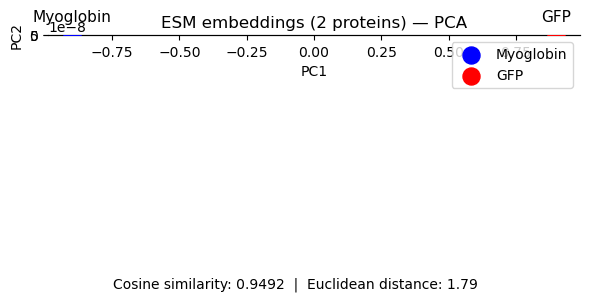

In [42]:
def plot_esm_pca(seq1, seq2, name1="Protein 1", name2="Protein 2"):
    """Plot PCA of ESM embeddings for two proteins."""
    emb1 = get_protein_embedding(seq1)
    emb2 = get_protein_embedding(seq2)
    X = np.vstack([emb1, emb2])
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    cos_sim = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
    euc_dist = np.linalg.norm(emb1 - emb2)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(X_pca[0, 0], X_pca[0, 1], c='blue', s=150, label=name1, zorder=3)
    ax.scatter(X_pca[1, 0], X_pca[1, 1], c='red', s=150, label=name2, zorder=3)
    ax.annotate(name1, (X_pca[0, 0], X_pca[0, 1]), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=11)
    ax.annotate(name2, (X_pca[1, 0], X_pca[1, 1]), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title('ESM embeddings (2 proteins) — PCA')
    ax.legend(loc='best')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect('equal')
    plt.figtext(0.5, 0.02, f'Cosine similarity: {cos_sim:.4f}  |  Euclidean distance: {euc_dist:.2f}', ha='center', fontsize=10)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

# Compare Myoglobin vs GFP: PCA of their ESM embeddings
seq_myo = "VLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRFKHLKTEAEMKASEDLKKHGVTVLTALGAILKKKGHHEAELKPLAQSHATKHKIPIKYLEFISEAIIHVLHSRHPGDFGADAQGAMNKALELFRKDIAAKYKELGYQG"
seq_gfp = "MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"
plot_esm_pca(seq_myo, seq_gfp, "Myoglobin", "GFP")

---

# **Question 1: Measuring Protein Proximity**

**YOUR TASK**: 

Below are three protein sequences. Your goal is to determine their relationship using ESM embeddings.

1. Calculate their ESM embeddings.
2. Calculate the **Cosine Similarity** between `seq_a` and `seq_b` and `seq_c`.


In [ ]:
# ============================================================
# EXERCISE : Calculate Distances
# ============================================================

seq_a = "VLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRFKHLKTEAEMKASEDLKKHGVTVLTALGAILKKKGHHEAELKPLAQSHATKHKIPIKYLEFISEAIIHVLHSRHPGDFGADAQGAMNKALELFRKDIAAKYKELGYQG"
seq_b = "GLSDGEWQLVLNVWGKVEADVAGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGNTVLTALGGILKKKGHHEAELTPLAQSHATKHKIPVKYLEFISEAIIQVLQSKHPGDFGADAQGAMSKALELFRNDMAAKYKELGFQG"
seq_c = "MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"

# TODO: Extract embeddings for all three proteins


# TODO: Calculate Cosine Similarity between A and B

# TODO: Calculate Cosine Similarity between A and C

# TODO: Calculate Cosine Similarity between B and C


# TODO: Print the results and compare them

### **Reflection Questions:**
1. Based on the similarity values, which pair of proteins is more biologically related?
3. Why do you think ESM, which only sees the sequence, can capture that Sperm Whale and Pig myoglobins are similar even though they are different species?

---

# **Question 2: Visualizing Protein Populations**

**YOUR TASK**: 

We have a dataset of several proteins:

1. Extract embeddings for all proteins.
2. Use **PCA (Principal Component Analysis)** and UMAP to plot the embeddings 

Visualize the embeddings and answer the lab questions

### **Protein Populations:**

In [46]:
protein_data = [
    # Globins (Family: Globin)
    {"pdb_id": "1MBN", "name": "Sperm Whale Myoglobin", "family": "Globin", "seq": "VLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRFKHLKTEAEMKASEDLKKHGVTVLTALGAILKKKGHHEAELKPLAQSHATKHKIPIKYLEFISEAIIHVLHSRHPGDFGADAQGAMNKALELFRKDIAAKYKELGYQG"},
    {"pdb_id": "1PMB", "name": "Pig Myoglobin", "family": "Globin", "seq": "GLSDGEWQLVLNVWGKVEADVAGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGNTVLTALGGILKKKGHHEAELTPLAQSHATKHKIPVKYLEFISEAIIQVLQSKHPGDFGADAQGAMSKALELFRNDMAAKYKELGFQG"},
    {"pdb_id": "1AZI", "name": "Human Myoglobin", "family": "Globin", "seq": "GLSDGEWQQVLNVWGKVEADIAGHGQEVLIRLFTGHPETLEKFDKFKHLKTEAEMKASEDLKKHGTVVLTALGGILKKKGHHEAELKPLAQSHATKHKIPIKYLEFISDAIIHVLHSKHPGDFGADAQGAMTKALELFRNDIAAKYKELGFQG"},
    {"pdb_id": "2DHB", "name": "Human Hemoglobin Alpha", "family": "Globin", "seq": "VQLSGEEKAAVLALWDKVNEEEVGGEALGRLLVVYPWTQRFFDSFGDLSNPGAVMGNPKVKAHGKKVLHSFGEGVHHLDNLKGTFAALSELHCDKLHVDPENFRLLGNVLALVVARHFGKDFTPELQASYQKVVAGVANALAHKYH"},
    {"pdb_id": "2HHB", "name": "Human Hemoglobin Beta", "family": "Globin", "seq": "VLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR"},
    {"pdb_id": "1ECO", "name": "Earthworm Hemoglobin", "family": "Globin", "seq": "LSADQISTVQASFDKVKGDPVGILYAVFKADPSIMAKFTQFAGKDLESIKGTAPFETHANRIVGFFSKIIGELPNIEADVNTFVASHKPRGVTHDQLNNFRAGFVSYMKAHTDFAGAEAAWGATLDTFFGMIFSKM"},
    {"pdb_id": "1VHB", "name": "Vitreoscilla Hemoglobin", "family": "Globin", "seq": "MLDQQTINIIKATVPVLKEHGVTITTTFYKNLFAKHPEVRPLFDMGRQESLEQPKALAMTVLAAAQNIENLPAILPAVKKIAVKHCQAGVAAAHYPIVGQELLGAIKEVLGDAATDDILDAWGKAYGVIADVFIQVEADLYAQAVE"},
    {"pdb_id": "1ITH", "name": "Loggerhead Sea Turtle Myoglobin", "family": "Globin", "seq": "GLTAAQIKAIQDHWFLNIKGCLQAAADSIFFKYLTAYPGDLAFFHKFSSVPLYGLRSNPAYKAQTLTVINYLDKVVDALGGNAGALMKAKVPSHDAMGITPKHFGQLLKLVGGVFQEEFSADPTTVAAWGDAAGVLVAAMK"},
    {"pdb_id": "1FLP", "name": "Yellowfin Tuna Myoglobin", "family": "Globin", "seq": "SLEAAQKSNVTSSWAKASAAWGTAGPEFFMALFDAHDDVFAKFSGLFSGAAKGTVKNTPEMAAQAQSFKGLVSNWVDNLDNAGALEGQCKTFAANHKARGISAGQLEAAFKVLSGFMKSYGGDEGAWTAVAGALMGEIEPDM"},
    {"pdb_id": "1MYG", "name": "Loggerhead Sea Turtle Myoglobin", "family": "Globin", "seq": "GLSDGEWQLVLNVWGKVEADVAGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGNTVLTALGGILKKKGHHEAELTPLAQSHATKHKIPVKYLEFISEAIIQVLQSKHPGDFGADAQGAMSKALELFRNDMAAKYKELGFQG"},
    {"pdb_id": "1A6M", "name": "Sperm Whale Myoglobin mutant", "family": "Globin", "seq": "VLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRFKHLKTEAEMKASEDLKKHGVTVLTALGAILKKKGHHEAELKPLAQSHATKHKIPIKYLEFISEAIIHVLHSRHPGDFGADAQGAMNKALELFRKDIAAKYKELGY"},
    {"pdb_id": "1OUT", "name": "Yellow-bellied Sea Snake Myoglobin", "family": "Globin", "seq": "VEWTDAEKSTISAVWGKVNIDEIGPLALARVLIVYPWTQRYFGSFGNVSTPAAIMGNPKVAAHGKVVCGALDKAVKNMGNILATYKSLSETHANKLFVDPDNFRVLADVLTIVIAAKFGASFTPEIQATWQKFMKVVVAAMGSRYF"},
    {"pdb_id": "1S60", "name": "Antarctic Fish Myoglobin", "family": "Globin", "seq": "MGSSHHHHHHSSGLVPRGSHMDIRQMNKTHLEHWRGLRKQLWPGHPDDAHLADGEEILQADHLASFIAMADGVAIGFADASIRHDYVNGCDSSPVVFLEGIFVLPSFRQRGVAKQLIAAVQRWGTNKGCREMASDTSPENTISQKVHQALGFEETERVIFYRKRC"},

    # Kinases (Family: Kinase)
    {"pdb_id": "2SRC", "name": "Human c-Src", "family": "Kinase", "seq": "MVTTFVALYDYESRTETDLSFKKGERLQIVNNTEGDWWLAHSLSTGQTGYIPSNYVAPSDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCPTSKPQTQGLAKDAWEIPRESLRLEVKLGQGCFGEVWMGTWNGTTRVAIKTLKPGTMSPEAFLQEAQVMKKLRHEKLVQLYAVVSEEPIYIVTEYMSKGSLLDFLKGETGKYLRLPQLVDMAAQIASGMAYVERMNYVHRDLRAANILVGENLVCKVADFGLARLIEDNEYTARQGAKFPIKWTAPEAALYGRFTIKSDVWSFGILLTELTTKGRVPYPGMVNREVLDQVERGYRMPCPPECPESLHDLMCQCWRKEPEERPTFEYLQAFLEDYFTSTEPQYQPGENL"},
    {"pdb_id": "1FMK", "name": "Human c-Src", "family": "Kinase", "seq": "MVTTFVALYDYESRTETDLSFKKGERLQIVNNTEGDWWLAHSLSTGQTGYIPSNYVAPSDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCPTSKPQTQGLAKDAWEIPRESLRLEVKLGQGCFGEVWMGTWNGTTRVAIKTLKPGTMSPEAFLQEAQVMKKLRHEKLVQLYAVVSEEPIYIVTEYMSKGSLLDFLKGETGKYLRLPQLVDMAAQIASGMAYVERMNYVHRDLRAANILVGENLVCKVADFGLARLIEDNEYTARQGAKFPIKWTAPEAALYGRFTIKSDVWSFGILLTELTTKGRVPYPGMVNREVLDQVERGYRMPCPPECPESLHDLMCQCWRKEPEERPTFEYLQAFLEDYFTSTEPQYQPGENL"},
    {"pdb_id": "3CS9", "name": "Human Abl", "family": "Kinase", "seq": "GAMDPSPNYDKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEDTMEVEEFLKEAAVMKEIKHPNLVQLLGVCTREPPFYIITEFMTYGNLLDYLRECNRQEVNAVVLLYMATQISSAMEYLEKKNFIHRDLAARNCLVGENHLVKVADFGLSRLMTGDTYTAHAGAKFPIKWTAPESLAYNKFSIKSDVWAFGVLLWEIATYGMSPYPGIDLSQVYELLEKDYRMERPEGCPEKVYELMRACWQWNPSDRPSFAEIHQAFETMFQES"},
    {"pdb_id": "1OPK", "name": "PKA", "family": "Kinase", "seq": "GAMDPSEALQRPVASDFEPQGLSEAARWNSKENLLAGPSENDPNLFVALYDFVASGDNTLSITKGEKLRVLGYNHNGEWCEAQTKNGQGWVPSNYITPVNSLEKHSWYHGPVSRNAAEYLLSSGINGSFLVRESESSPGQRSISLRYEGRVYHYRINTASDGKLYVSSESRFNTLAELVHHHSTVADGLITTLHYPAPKRNKPTIYGVSPNYDKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEDTMEVEEFLKEAAVMKEIKHPNLVQLLGVCTREPPFYIITEFMTYGNLLDYLRECNRQEVSAVVLLYMATQISSAMEYLEKKNFIHRNLAARNCLVGENHLVKVADFGLSRLMTGDTYTAHAGAKFPIKWTAPESLAYNKFSIKSDVWAFGVLLWEIATYGMSPYPGIDLSQVYELLEKDYRMERPEGCPEKVYELMRACWQWNPSDRPSFAEIHQAFETMFQESSISDEVEKELGKRGT"},
    {"pdb_id": "1IRK", "name": "Insulin Receptor Kinase", "family": "Kinase", "seq": "VFPSSVFVPDEWEVSREKITLLRELGQGSFGMVYEGNARDIIKGEAETRVAVKTVNESASLRERIEFLNEASVMKGFTCHHVVRLLGVVSKGQPTLVVMELMAHGDLKSYLRSLRPEAENNPGRPPPTLQEMIQMAAEIADGMAYLNAKKFVHRDLAARNCMVAHDFTVKIGDFGMTRDIYETDYYRKGGKGLLPVRWMAPESLKDGVFTTSSDMWSFGVVLWEITSLAEQPYQGLSNEQVLKFVMDGGYLDQPDNCPERVTDLMRMCWQFNPKMRPTFLEIVNLLKDDLHPSFPEVSFFHSEENK"},
    {"pdb_id": "1FGK", "name": "FGFR1 Kinase", "family": "Kinase", "seq": "MVAGVSEYELPEDPRWELPRDRLVLGKPLGEGAFGQVVLAEAIGLDKDKPNRVTKVAVKMLKSDATEKDLSDLISEMEMMKMIGKHKNIINLLGACTQDGPLYVIVEYASKGNLREYLQARRPPGLEYSYNPSHNPEEQLSSKDLVSCAYQVARGMEYLASKKCIHRDLAARNVLVTEDNVMKIADFGLARDIHHIDYYKKTTNGRLPVKWMAPEALFDRIYTHQSDVWSFGVLLWEIFTLGGSPYPGVPVEELFKLLKEGHRMDKPSNCTNELYMMMRDCWHAVPSQRPTFKQLVEDLDRIVALTSNQE"},
    {"pdb_id": "2PHK", "name": "Phosphorylase Kinase", "family": "Kinase", "seq": "GFYENYEPKEILGRGVSSVVRRCIHKPTCKEYAVKIIDVTGGGSFSAEEVQELREATLKEVDILRKVSGHPNIIQLKDTYETNTFFFLVFDLMKKGELFDYLTEKVTLSEKETRKIMRALLEVICALHKLNIVHRDLKPENILLDDDMNIKLTDFGFSCQLDPGEKLREVCGTPSYLAPEIIECSMNDNHPGYGKEVDMWSTGVIMYTLLAGSPPFWHRKQMLMLRMIMSGNYQFGSPEWDDYSDTVKDLVSRFLVVQPQKRYTAEEALAHPFFQQY"},
    {"pdb_id": "1CKP", "name": "Casein Kinase", "family": "Kinase", "seq": "MENFQKVEKIGEGTYGVVYKARNKLTGEVVALKKIRLDTETEGVPSTAIREISLLKELNHPNIVKLLDVIHTENKLYLVFEFLHQDLKKFMDASALTGIPLPLIKSYLFQLLQGLAFCHSHRVLHRDLKPQNLLINTEGAIKLADFGLARAFGVPVRTYTHEVVTLWYRAPEILLGCKYYSTAVDIWSLGCIFAEMVTRRALFPGDSEIDQLFRIFRTLGTPDEVVWPGVTSMPDYKPSFPKWARQDFSKVVPPLDEDGRSLLSQMLHYDPNKRISAKAALAHPFFQDVTKPVPHLRL"},
    {"pdb_id": "1ATP", "name": "PKA", "family": "Kinase", "seq": "TTYADFIASGRTGRRNAIHD"},
    {"pdb_id": "3P5O", "name": "EGFR", "family": "Kinase", "seq": "SMNPPPPETSNPNKPKRQTNQLQYLLRVVLKTLWKHQFAWPFQQPVDAVKLNLPDYYKIIKTPMDMGTIKKRLENNYYWNAQECIQDFNTMFTNCYIYNKPGDDIVLMAEALEKLFLQKINELPTEE"},
    {"pdb_id": "2F4J", "name": "MET Kinase", "family": "Kinase", "seq": "GMSPNYDKWEMERTDITMKHKLGGGQYGEVYEGVWKKYSLTVAVKTLKEDTMEVEEFLKEAAVMKEIKHPNLVQLLGVCTREPPFYIITEFMTYGNLLDYLRECNRQEVNAVVLLYMATQISSAMEYLEKKNFIHRDLAARNCLVGENHLVKVADFGLSRLMTGDTYTAPAGAKFPIKWTAPESLAYNKFSIKSDVWAFGVLLWEIATYGMSPYPGIDLSQVYELLEKDYRMERPEGCPEKVYELMRACWQWNPSDRPSFAEIHQAFETMFQESSISDEVEKELGKQ"},
    {"pdb_id": "1M17", "name": "EGFR", "family": "Kinase", "seq": "GSHMASGEAPNQALLRILKETEFKKIKVLGSGAFGTVYKGLWIPEGEKVKIPVAIKELREATSPKANKEILDEAYVMASVDNPHVCRLLGICLTSTVQLITQLMPFGCLLDYVREHKDNIGSQYLLNWCVQIAKGMNYLEDRRLVHRDLAARNVLVKTPQHVKITDFGLAKLLGAEEKEYHAEGGKVPIKWMALESILHRIYTHQSDVWSYGVTVWELMTFGSKPYDGIPASEISSILEKGERLPQPPICTIDVYMIMVKCWMIDADSRPKFRELIIEFSKMARDPQRYLVIQGDERMHLPSPTDSNFYRALMDEEDMDDVVDADEYLIPQQG"},
    {"pdb_id": "2GS7", "name": "EGFR", "family": "Kinase", "seq": "GAMGEAPNQALLRILKETEFKKIKVLGSGAFGTVYKGLWIPEGEKVKIPVAIKELREATSPKANKEILDEAYVMASVDNPHVCRLLGICLTSTVQLITQLMPFGCLLDYVREHKDNIGSQYLLNWCVQIAKGMNYLEDRRLVHRDLAARNVLVKTPQHVKITDFGLAKLLGAEEKEYHAEGGKVPIKWMALESILHRIYTHQSDVWSYGVTVWELMTFGSKPYDGIPASEISSILEKGERLPQPPICTIDVYMIMRKCWMIDADSRPKFRELIIEFSKMARDPQRYLVIQGDERMHLPSPTDSNFYRALMDEEDMDDVVDADEYLIPQQG"},
    {"pdb_id": "2CMW", "name": "Aurora A", "family": "Kinase", "seq": "SMRVGKKIGCGNFGELRLGKNLYTNEYVAIKLEPIKSRAPQLHLEYRFYKQLGSAGEGLPQVYYFGPCGKYNAMVLELLGPSLEDLFDLCDRTFTLKTVLMIAIQLLSRMEYVHSKNLIYRDVKPENFLIGRQGNKKEHVIHIIDFGLAKEYIDPETKKHIPYREHKSLTGTARYMSINTHLGKEQSRRDDLEALGHMFMYFLRGSLPWQGLKADTLKERYQKIGDTKRNTPIEALCENFPEEMATYLRYVRRLDFFEKPDYEYLRTLFTDLFEKKGYTFDYAYDWVGRPIPTPVGSVHVDSGASAITRE"},

    # Cytochromes (Family: Cytochrome)
    {"pdb_id": "1HRC", "name": "Horse Cytochrome c", "family": "Cytochrome", "seq": "GDVEKGKKIFVQKCAQCHTVEKGGKHKTGPNLHGLFGRKTGQAPGFTYTDANKNKGITWKEETLMEYLENPKKYIPGTKMIFAGIKKKTEREDLIAYLKKATNE"},
    {"pdb_id": "1YCC", "name": "Yeast Cytochrome c", "family": "Cytochrome", "seq": "TEFKAGSAKKGATLFKTRCLQCHTVEKGGPHKVGPNLHGIFGRHSGQAEGYSYTDANIKKNVLWDENNMSEYLTNPKKYIPGTKMAFGGLKKEKDRNDLITYLKKACE"},
    {"pdb_id": "3ZCF", "name": "Human Cytochrome c", "family": "Cytochrome", "seq": "GDVEKGKKIFIMKCSQCHTVEKGGKHKTGPNLHGLFGRKTGQAPGYSYTAANKNKGIIWGEDTLMEYLENPKKYIPGTKMIFVGIKKKEERADLIAYLKKATNE"},
    {"pdb_id": "1J3S", "name": "Human Cytochrome c", "family": "Cytochrome", "seq": "GDVEKGKKIFIMKCSQCHTVEKGGKHKTGPNLHGLFGRKTGQAPGYSYTAANKNKGIIWGEDTLMEYLENPKKYIPGTKMIFVGIKKKEERADLIAYLKKATNE"},
    {"pdb_id": "1CYC", "name": "Tuna Cytochrome c", "family": "Cytochrome", "seq": "GDVAKGKKTFVQKCAQCHTVENGGKHKVGPNLWGLFGRKTGQAEGYSYTDANKSKGIVWNENTLMEYLENPKKYIPGTKMIFAGIKKKGERQDLVAYLKSATS"},
    {"pdb_id": "5CYT", "name": "Albumin-like Cytochrome c", "family": "Cytochrome", "seq": "GDVAKGKKTFVQKCAQCHTVENGGKHKVGPNLWGLFGRKTGQAEGYSYTDANKSKGIVWNNDTLMEYLENPKKYIPGTKMIFAGIKKKGERQDLVAYLKSATS"},
    {"pdb_id": "1C75", "name": "Rhodobacter capsulatus Cytochrome c2", "family": "Cytochrome", "seq": "VDAEAVVQQKCISCHGGDLTGASAPAIDKAGANYSEEEILDIILNGQGGMPGGIAKGAEAEAVAAWLAEKK"},
    {"pdb_id": "1AYG", "name": "Cytochrome c6", "family": "Cytochrome", "seq": "NEQLAKQKGCMACHDLKAKKVGPAYADVAKKYAGRKDAVDYLAGKIKKGGSGVWGSVPMPPQNVTDAEAKQLAQWILSIK"},
    {"pdb_id": "1C2R", "name": "Cytochrome c550", "family": "Cytochrome", "seq": "GDAAKGEKEFNKCKTCHSIIAPDGTEIVKGAKTGPNLYGVVGRTAGTYPEFKYKDSIVALGASGFAWTEEDIATYVKDPGAFLKEKLDDKKAKTGMAFKLAKGGEDVAAYLASVVK"},
    {"pdb_id": "1C52", "name": "Pseudomonas aeruginosa Cytochrome 553", "family": "Cytochrome", "seq": "QADGAKIYAQCAGCHQQNGQGIPGAFPPLAGHVAEILAKEGGREYLILVLLYGLQGQIEVKGMKYNGVMSSFAQLKDEEIAAVLNHIATAWGDAKKVKGFKPFTAEEVKKLRAKKLTPQQVLAERKKLGLK"},
    {"pdb_id": "1CC5", "name": "Cytochrome c5", "family": "Cytochrome", "seq": "GGGARSGDDVVAKYCNACHGTGLLNAPKVGDSAAWKTRADAKGGLDGLLAQSLSGLNAMPPKGTCADCSDDELKAAIGKMSGL"},
    {"pdb_id": "1M60", "name": "Cytochrome c'", "family": "Cytochrome", "seq": "GDVEKGKKIFVQKCAQCHTVEKGGKHKTGPNLHGLFGRKTGQAPGFTYTDANKNKGITWKEETLMEYLENPKKYIPGTKMIFAGIKKKTEREDLIAYLKKATNE"},
    {"pdb_id": "2B4Z", "name": "Cytochrome c6", "family": "Cytochrome", "seq": "GDVEKGKKIFVQKCAQCHTVEKGGKHKTGPNLHGLFGRKTGQAPGFSYTDANKNKGITWGEETLMEYLENPKKYIPGTKMIFAGIKKKGEREDLIAYLKKATNE"},
    {"pdb_id": "1YEA", "name": "Yeast Cytochrome c variant", "family": "Cytochrome", "seq": "AKESTGFKPGSAKKGATLFKTRCQQCHTIEEGGPNKVGPNLHGIFGRHSGQVKGYSYTDANINKNVKWDEDSMSEYLTNPKKYIPGTKMAFAGLKKEKDRNDLITYMTKAAK"},

    # Something Else
    {"pdb_id": "1GFL", "name": "GFP", "family": "Other", "seq": "MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"},
]



In [47]:
# TODO: Extract embeddings for all proteins in the list


# TODO: Run PCA to reduce embeddings to 2 components


# TODO: Create a Plotly Scatter plot
# Hint: Use plt.scatter(df['pca1'], df['pca2'], c=df['family'].astype('category').cat.codes); annotate with df['name']